<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/main/SkinLesionTriage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#metadaten als auch images sind in drive gespeichert
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Mounted at /content/drive


In [11]:
csv_path = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_metadata.csv'
df = pd.read_csv(csv_path)

# 'mel' (Melanom) wird zu 1, alles andere wird zu 0 (Gutartig)
df['label'] = (df['dx'] == 'mel').astype(int)

print(f"Shape der Daten : {df.shape}")
print(f"Anzahl der Dimensionen : {df.ndim}")
print("\nVerteilung der Klassen (0=Gutartig, 1=Melanom):")
print(df['label'].value_counts())

print("\nDie ersten 5 Zeilen (Head):")
df.head()

Shape der Daten : (10015, 8)
Anzahl der Dimensionen : 2

Verteilung der Klassen (0=Gutartig, 1=Melanom):
label
0    8902
1    1113
Name: count, dtype: int64

Die ersten 5 Zeilen (Head):


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0


/tmp/ipykernel_7635/1285734021.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'], legend=False)


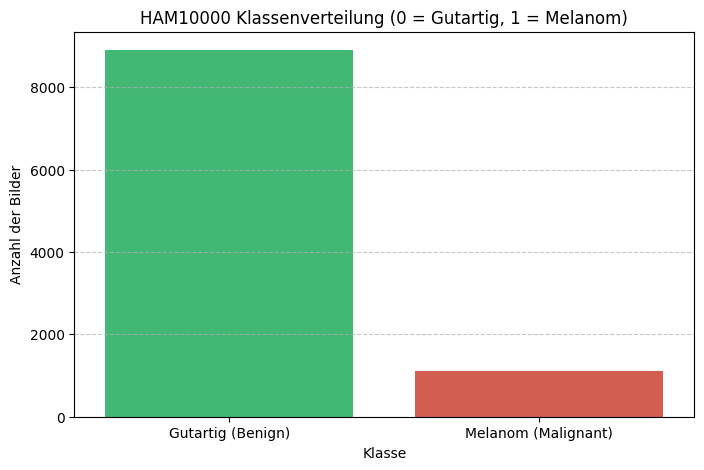

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('HAM10000 Klassenverteilung (0 = Gutartig, 1 = Melanom)')
plt.xlabel('Klasse')
plt.ylabel('Anzahl der Bilder')
plt.xticks([0, 1], ['Gutartig (Benign)', 'Melanom (Malignant)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Trainings-Bilder: 7010
Validation-Bilder: 1002
Test-Bilder: 2003


/tmp/ipykernel_7635/1634085279.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_split, palette=['#2ecc71', '#e74c3c'], legend=False)


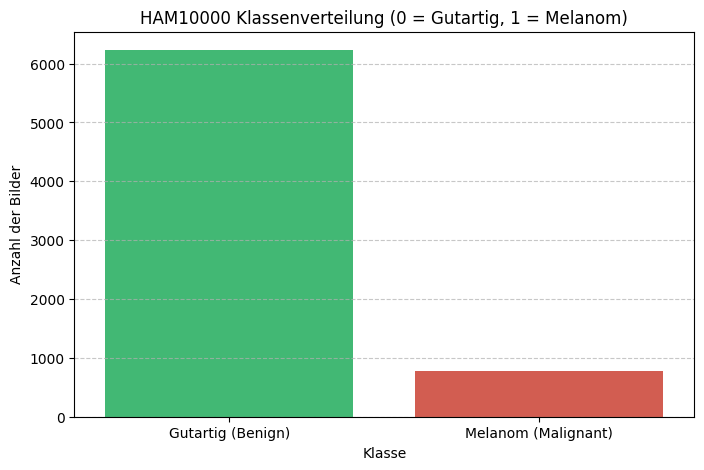

/tmp/ipykernel_7635/1634085279.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_split, palette=['#2ecc71', '#e74c3c'], legend=False)


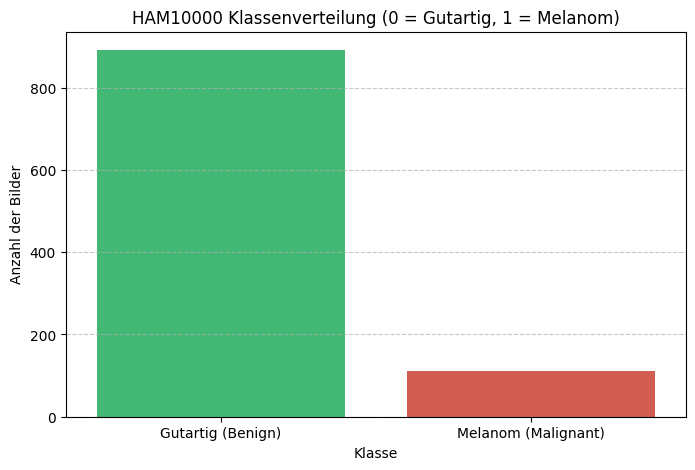

/tmp/ipykernel_7635/1634085279.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_split, palette=['#2ecc71', '#e74c3c'], legend=False)


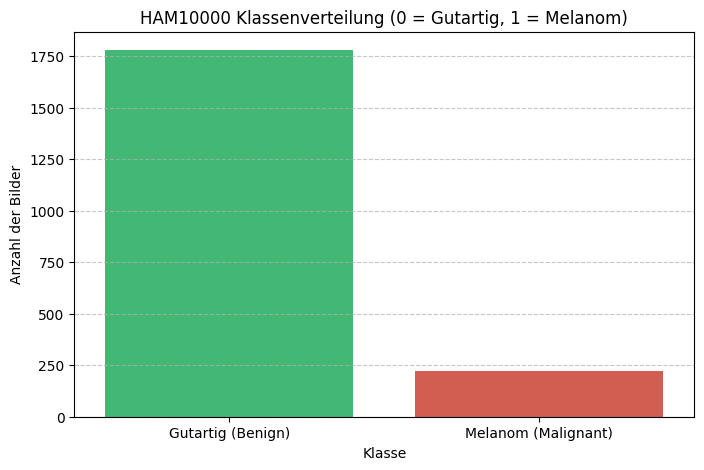

In [17]:

train_val_df, test_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42) # 42 seed

# von den 80% werden 12,5% abgezogen
train_df, val_df = train_test_split(train_val_df, test_size=0.125, stratify=train_val_df['label'], random_state=42)

print(f"Trainings-Bilder: {len(train_df)}")
print(f"Validation-Bilder: {len(val_df)}")
print(f"Test-Bilder: {len(test_df)}")

dataset = [train_df, val_df, test_df]

for df_split in dataset:
  plt.figure(figsize=(8, 5))
  sns.countplot(x='label', data=df_split, palette=['#2ecc71', '#e74c3c'], legend=False)
  plt.title('HAM10000 Klassenverteilung (0 = Gutartig, 1 = Melanom)')
  plt.xlabel('Klasse')
  plt.ylabel('Anzahl der Bilder')
  plt.xticks([0, 1], ['Gutartig (Benign)', 'Melanom (Malignant)'])
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# EfficientNet-B0 will 224x224 andere resolution sind auch möglich und ImageNet-Normalisierung
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # soll gegen overfitting helfen
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset-Klasse
class SkinDataset(Dataset):
    def init(self, dataframe, img_dirs, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dirs = img_dirs
        self.transform = transform

    def len(self):
        return len(self.data)

    def getitem(self, idx):
        img_name = self.data.loc[idx, 'image_id'] + '.jpg'
        img_path = None

        # In beiden Ordnern suchen
        for directory in self.img_dirs:
            temp_path = os.path.join(directory, img_name)
            if os.path.exists(temp_path):
                img_path = temp_path
                break

        if img_path is None:
            raise FileNotFoundError(f"Bild {img_name} nicht gefunden!")

        image = Image.open(img_path).convert('RGB')
        label = self.data.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)

        # PyTorch erwartet Labels als Float für den binären Loss (BCEWithLogitsLoss)
        return image, torch.tensor(label, dtype=torch.float32)

# Pfade zu den Bildern
bild_ordner = [
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_images_part_1',
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_images_part_2'
]

# Datensätze erstellen
train_dataset = SkinDataset(train_df, bild_ordner, transform=train_transforms)
val_dataset = SkinDataset(val_df, bild_ordner, transform=test_transforms)
test_dataset = SkinDataset(test_df, bild_ordner, transform=test_transforms)

# DataLoader erstellen
b_size = 32
train_loader = DataLoader(train_dataset, batch_size=b_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=b_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=b_size, shuffle=False)

print("ok")

ok
